In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

boxes = [
    (4300, 40, '#ff7f0e', 'Jet-Tagger'),
    (18944, 40, '#17becf', 'τ Event Selection'),
    (34800, 40, '#2ca02c', 'VAE at LHC (Large)'),
    (82900, 40, '#d62728', 'QBit Readout'),
    (116700, 40, '#9467bd', 'Deep Autoencoder'),
]

box_size = 80
x_min = 2048
blue_line_color = '#1f77b4'
red_line_color = '#8b0000'
line_width = 1.2
blue_fill_color = '#dbeafe'
red_fill_color = '#fee2e2'
fill_alpha = 0.8
trigger_y = 40
trigger_line_color = '#d62728'
trigger_text = 'LHC Trigger Frequency: 40 MHz'
trigger_text_x = 23000
trigger_text_y = 44


In [2]:
macs = [2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]#, 524288, 1048576]


In [3]:
blue_line_mhz = [
    52.083333333,
    52.083333333,
    52.083333333,
    52.083333333,
    28.40909091,
    14.88095238,
    8.680555556,
    4.528985507,
    #2.34962406,
    #0.603281853,
]


In [4]:
red_line_mhz = [101, 101, 101, 87.9, 82.5, 63.0, 54.9, 46.34]#, 37, 22]


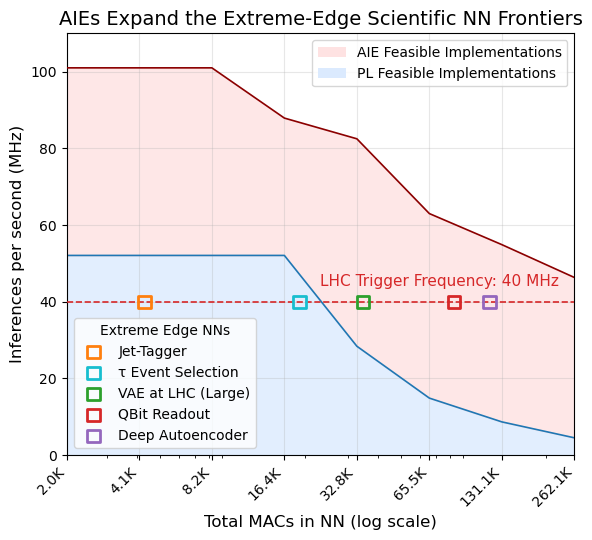

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.fill_between(macs, 0, blue_line_mhz, color=blue_fill_color, alpha=fill_alpha, zorder=0)
ax.fill_between(macs, blue_line_mhz, red_line_mhz, color=red_fill_color, alpha=fill_alpha, zorder=1)
ax.plot(macs, blue_line_mhz, linewidth=line_width, color=blue_line_color, zorder=2)
ax.plot(macs, red_line_mhz, linewidth=line_width, color=red_line_color, zorder=3)
ax.axhline(trigger_y, color=trigger_line_color, linestyle='--', linewidth=line_width, zorder=4)
ax.set_xlabel('Total MACs in NN (log scale)', fontsize=12)
ax.set_ylabel('Inferences per second (MHz)', fontsize=12)
ax.set_title('AIEs Expands the Extreme-Edge Scientific NN Frontiers', fontsize=14)
ax.set_xscale('log')
ax.set_ylim(0,110)
ax.set_xlim(x_min, max(macs) )
ax.set_xticks(macs)
ax.set_xticklabels([f'{x / 1000:.1f}K' for x in macs])
for x, y, color, label in boxes:
    ax.scatter([x], [y], marker='s', s=box_size, facecolors='none', edgecolors=color, linewidths=2, zorder=5, label=label)
ax.text(trigger_text_x, trigger_text_y, trigger_text, color=trigger_line_color, fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3)
nn_legend = ax.legend(loc='lower left', title='Extreme Edge NNs')
ax.add_artist(nn_legend)
region_handles = [
    Patch(facecolor=red_fill_color, edgecolor='none', alpha=1.0, label='AIE Feasible Implementations'),
    Patch(facecolor=blue_fill_color, edgecolor='none', alpha=1.0, label='PL Feasible Implementations'),
]
ax.legend(handles=region_handles, loc='upper right')
fig.tight_layout()
plt.show()
